# 02 · Mujeres cuidadoras en la CDMX — exploración enfocada

**Pregunta rectora:** ¿dónde y cuánto trabajo de cuidado recae sobre las mujeres de la CDMX, y qué tanto lo alivia la oferta de cuidados que tienen cerca?

La unidad de análisis es **la mujer cuidadora**. Las demás variables (población que requiere cuidado, establecimientos) entran como contexto de su carga. Los hombres aparecen solo como **línea de referencia** para dimensionar la brecha, nunca como tema.

| Bloque | Fuente | Qué responde | Nivel |
|---|---|---|---|
| 1 | ENUT 2024 | ¿Cuánto cuidan las mujeres de la CDMX y quiénes cuidan más? | CDMX |
| 2 | ENASIC 2022 | ¿Qué les impide apoyarse en servicios? ¿Quién podría cuidar a cambio de pago? | Nacional (no trae geografía) |
| 3 | Censo 2020 | ¿Dónde es mayor la carga potencial por mujer? | AGEB urbana |
| 4 | DENUE 05/2026 + Censo | ¿Dónde cuidan sin respaldo cercano? | AGEB urbana |

**Cómo correrlo:** de arriba abajo. Descarga las fuentes a `data/raw/` si no existen (las mismas del notebook 01). Salidas en `data/curada/` y `figuras/`.

In [1]:
from pathlib import Path
import shutil, urllib.request, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)

# Raíz del repo: los notebooks viven en notebooks/, así que subimos un nivel.
# Así `data/` y `figuras/` se resuelven igual desde Jupyter o desde la raíz.
BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW, CUR, FIG = BASE / 'data' / 'raw', BASE / 'data' / 'curada', BASE / 'figuras'
for p in (RAW, CUR, FIG):
    p.mkdir(parents=True, exist_ok=True)

FUENTES = {
    'denue_09': 'https://www.inegi.org.mx/contenidos/masiva/denue/denue_09_csv.zip',
    'censo_ageb_09': 'https://www.inegi.org.mx/contenidos/programas/ccpv/2020/datosabiertos/ageb_manzana/ageb_mza_urbana_09_cpv2020_csv.zip',
    'enut_2024': 'https://www.inegi.org.mx/contenidos/programas/enut/2024/datosabiertos/conjunto_de_datos_enut_2024_csv.zip',
    'enasic_2022': 'https://www.inegi.org.mx/contenidos/programas/enasic/2022/datosabiertos/conjunto_de_datos_enasic_2022_csv.zip',
}

def descargar(nombre, url):
    zpath, dpath = RAW / f'{nombre}.zip', RAW / nombre
    if not zpath.exists():
        print(f'Descargando {nombre}...')
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as r, open(zpath, 'wb') as f:
            shutil.copyfileobj(r, f)
    if not dpath.exists():
        with zipfile.ZipFile(zpath) as z:
            z.extractall(dpath)
    return dpath

DIRS = {k: descargar(k, u) for k, u in FUENTES.items()}

MORADO, GRIS = '#7b3f98', '#9a9a9a'   # mujeres / referencia

---
## 1. ENUT 2024 — cuánto cuidan las mujeres de la CDMX

Método validado en el notebook 01: con factores de expansión y promedios entre quienes realizan la actividad, se reproducen exactamente las cifras publicadas por el INEGI (59.6 h de trabajo total; 61.1 mujeres, 58.0 hombres).

Horas **sin cuidados pasivos** (solo tiempo activo de cuidado).

In [2]:
enut = pd.read_csv(next(DIRS['enut_2024'].rglob('*tvar_crea*/conjunto_de_datos/*.csv')),
                   dtype=str, encoding='utf-8-sig')
horas = list(enut.columns[3:41])
for c in horas + ['fac_per', 'edad']:
    enut[c] = pd.to_numeric(enut[c], errors='coerce')

enut['sexo_t'] = enut['sexo'].map({'1': 'Hombres', '2': 'Mujeres'})
enut['condicion'] = enut['cond_aee'].map({
    '1': 'Ocupada', '2': 'Desocupada', '3': 'Jubilada o pensionada', '4': 'Estudiante',
    '5': 'Dedicada al hogar o al cuidado', '6': 'Otra situación'})
enut['grupo_edad'] = pd.cut(enut['edad'], [11, 17, 29, 44, 59, 120],
                            labels=['12–17', '18–29', '30–44', '45–59', '60+'])

cdmx = enut[enut['cve_ent'] == '09']
mujeres = cdmx[cdmx['sexo_t'] == 'Mujeres']
hombres = cdmx[cdmx['sexo_t'] == 'Hombres']

def pct(d, col):
    return d.loc[d[col] > 0, 'fac_per'].sum() / d['fac_per'].sum() * 100

def horas_part(d, col):
    d = d[d[col] > 0]
    return np.average(d[col], weights=d['fac_per']) if len(d) else np.nan

def horas_pob(d, col):
    return np.average(d[col], weights=d['fac_per'])

print(f'Muestra CDMX: {len(mujeres):,} mujeres y {len(hombres):,} hombres de 12 años y más')

Muestra CDMX: 1,144 mujeres y 963 hombres de 12 años y más


### 1.1 La carga de cuidado de las mujeres, con la brecha como referencia

In [3]:
ACTIV = {
    'trab_no_rem_cuid_hog': 'Cuidado a integrantes del hogar (total)',
    'cuid_int_0a5_sin_cp': 'Cuidado a niñas y niños de 0 a 5',
    'cuid_int_6a14_sin_cp': 'Cuidado a niñas y niños de 6 a 14',
    'cuid_int_60mas_sin_cp': 'Cuidado a personas de 60+',
    'cuid_esp_int_hog_sin_cp': 'Cuidados especiales (enfermedad o discapacidad)',
    'trab_no_rem_hog': 'Trabajo doméstico no remunerado',
}
t = pd.DataFrame([{
    'actividad': nombre,
    '% de mujeres que lo realiza': pct(mujeres, col),
    'h/semana (mujeres que lo realizan)': horas_part(mujeres, col),
    'n mujeres': int((mujeres[col] > 0).sum()),
    'ref. h/semana hombres': horas_part(hombres, col),
} for col, nombre in ACTIV.items()]).round(1)
t['mujeres / hombres (h)'] = (t['h/semana (mujeres que lo realizan)'] / t['ref. h/semana hombres']).round(2)
t.to_csv(CUR / 'mujeres_enut_carga_cdmx.csv', index=False)
t

,actividad,% de mujeres que lo realiza,h/semana (mujeres que lo realizan),n mujeres,ref. h/semana hombres,mujeres / hombres (h)
0,Cuidado a integrantes del hogar (total),62.2,12.2,705,8.1,1.51
1,Cuidado a niñas y niños de 0 a 5,10.9,21.0,122,9.9,2.12
2,Cuidado a niñas y niños de 6 a 14,18.1,11.0,204,7.2,1.53
3,Cuidado a personas de 60+,11.3,4.8,129,4.9,0.98
4,Cuidados especiales (enfermedad o discapacidad),7.2,13.8,77,6.5,2.12
5,Trabajo doméstico no remunerado,98.7,24.5,1130,13.4,1.83


### 1.2 La doble jornada: trabajo pagado + no pagado de las mujeres ocupadas

In [4]:
def jornada(d):
    return pd.Series({
        'Trabajo para el mercado': horas_pob(d, 'activ_merc'),
        'Trabajo doméstico no remunerado': horas_pob(d, 'trab_no_rem_hog'),
        'Cuidado no remunerado': horas_pob(d, 'trab_no_rem_cuid_hog'),
    })

jor = pd.DataFrame({
    'Mujeres ocupadas': jornada(mujeres[mujeres['cond_aee'] == '1']),
    'Hombres ocupados (ref.)': jornada(hombres[hombres['cond_aee'] == '1']),
}).T
jor['Total'] = jor.sum(axis=1)
jor['n'] = [int((mujeres['cond_aee'] == '1').sum()), int((hombres['cond_aee'] == '1').sum())]
jor.round(1)

,Trabajo para el mercado,Trabajo doméstico no remunerado,Cuidado no remunerado,Total,n
Mujeres ocupadas,45.6,23.3,8.0,77.0,639
Hombres ocupados (ref.),54.8,13.1,5.6,73.5,689


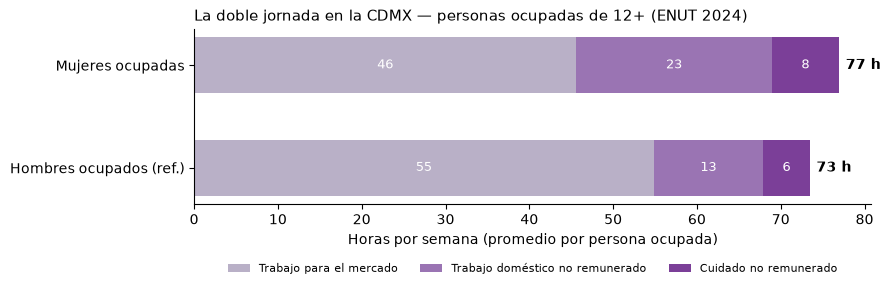

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.2))
colores = ['#b9b0c7', '#9a74b3', MORADO]
izq = np.zeros(len(jor))
for col, color in zip(['Trabajo para el mercado', 'Trabajo doméstico no remunerado', 'Cuidado no remunerado'], colores):
    ax.barh(jor.index, jor[col], left=izq, color=color, label=col, height=0.55)
    for i, v in enumerate(jor[col]):
        ax.text(izq[i] + v / 2, i, f'{v:.0f}', va='center', ha='center', fontsize=9, color='white')
    izq += jor[col].to_numpy()
for i, v in enumerate(jor['Total']):
    ax.text(v + 0.8, i, f'{v:.0f} h', va='center', fontsize=10, fontweight='bold')
ax.invert_yaxis()
ax.set_xlabel('Horas por semana (promedio por persona ocupada)')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(ncol=3, fontsize=8, frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.28))
ax.set_title('La doble jornada en la CDMX — personas ocupadas de 12+ (ENUT 2024)', loc='left', fontsize=11)
plt.tight_layout()
fig.savefig(FIG / 'mujeres_doble_jornada.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3 ¿Qué mujeres cuidan más?

Promedio de horas de cuidado por mujer (incluye a quienes no cuidan), por condición de actividad y por edad. Grupos con menos de 60 casos en la muestra se marcan como poco confiables.

In [6]:
def por_grupo(col_grupo):
    g = mujeres.groupby(col_grupo, observed=True)
    out = pd.DataFrame({
        'h/semana de cuidado (promedio por mujer)': g.apply(lambda d: horas_pob(d, 'trab_no_rem_cuid_hog'), include_groups=False),
        '% que cuida': g.apply(lambda d: pct(d, 'trab_no_rem_cuid_hog'), include_groups=False),
        'n': g.size(),
    }).round(1)
    out['confiable'] = np.where(out['n'] >= 60, 'sí', 'no — muestra chica')
    return out

por_cond = por_grupo('condicion').sort_values('h/semana de cuidado (promedio por mujer)', ascending=False)
por_cond

,h/semana de cuidado (promedio por mujer),% que cuida,n,confiable
condicion,,,,
Dedicada al hogar o al cuidado,9.7,59.6,290,sí
Ocupada,8.0,65.5,639,sí
Desocupada,3.8,78.2,4,no — muestra chica
Otra situación,3.7,25.2,20,no — muestra chica
Estudiante,3.4,65.8,121,sí
Jubilada o pensionada,2.9,45.9,70,sí


In [7]:
por_edad = por_grupo('grupo_edad')
por_edad

,h/semana de cuidado (promedio por mujer),% que cuida,n,confiable
grupo_edad,,,,
12–17,3.4,58.7,65,sí
18–29,8.5,74.8,213,sí
30–44,14.3,71.9,288,sí
45–59,5.5,61.2,269,sí
60+,3.3,45.8,309,sí


---
## 2. ENASIC 2022 — la relación de las cuidadoras con los servicios de cuidado

**Recordatorio:** ENASIC no trae ninguna variable geográfica en sus microdatos públicos. Todo lo de esta sección es **nacional** y se usa como marco para el diseño del programa, no como hallazgo de la CDMX.

Tabla usada: población cuidadora de 15+ (`tpob_cui`), filtrada a **mujeres**, con su factor de expansión (`FAC_CUI`).

In [8]:
cui = pd.read_csv(next(DIRS['enasic_2022'].rglob('*tpob_cui*/conjunto_de_datos/*.csv')),
                  dtype=str, encoding='utf-8-sig', low_memory=False)
cui['FAC_CUI'] = pd.to_numeric(cui['FAC_CUI'])
cuidadoras = cui[cui['SEXO'] == '2'].copy()
cuidadores = cui[cui['SEXO'] == '1'].copy()
W = lambda d: d['FAC_CUI'].sum()
print(f'Mujeres cuidadoras de 15+: {W(cuidadoras) / 1e6:.1f} millones '
      f'({W(cuidadoras) / W(cui) * 100:.1f}% del total) · registros: {len(cuidadoras):,}')

def dist(d, var, etiquetas):
    s = d.groupby(var)['FAC_CUI'].sum()
    return (s / s.sum() * 100).rename(index=etiquetas).round(1)

Mujeres cuidadoras de 15+: 23.8 millones (75.1% del total) · registros: 4,173


### 2.1 ¿A qué se dedican las mujeres cuidadoras?

In [9]:
COND = {'1': 'Trabajó', '2': 'Tenía trabajo pero no trabajó', '3': 'Buscó trabajo',
        '4': 'Pensionada o jubilada', '5': 'Estudiante',
        '6': 'Quehaceres del hogar o cuidado de hijas e hijos',
        '7': 'Limitación permanente para trabajar', '8': 'Otra situación'}
cond = pd.DataFrame({'Mujeres cuidadoras (%)': dist(cuidadoras, 'P5_6', COND),
                     'ref. hombres cuidadores (%)': dist(cuidadores, 'P5_6', COND)}).fillna(0)
cond.sort_values('Mujeres cuidadoras (%)', ascending=False)

,Mujeres cuidadoras (%),ref. hombres cuidadores (%)
P5_6,,
Quehaceres del hogar o cuidado de hijas e hijos,49.1,2.9
Trabajó,44.1,81.1
Estudiante,2.1,3.0
Pensionada o jubilada,1.7,6.2
Tenía trabajo pero no trabajó,1.4,2.5
Limitación permanente para trabajar,0.7,1.2
Buscó trabajo,0.4,1.8
Otra situación,0.4,1.2


### 2.2 ¿Usan servicios de cuidado? ¿Por qué no?

In [10]:
busco = dist(cuidadoras, 'P6_42', {'1': 'Sí buscó', '2': 'No buscó'})
print('¿Buscó guardería, casa de día o asilo desde oct-2021? (mujeres cuidadoras)')
print(busco.to_string(), '\n')

RAZONES = {
    'P6_45_01': 'El propio hogar cuida', 'P6_45_02': 'Apoyan otros familiares o conocidos',
    'P6_45_03': 'Son caros', 'P6_45_04': 'Le preocupa el qué dirán',
    'P6_45_05': 'No sabe que existen', 'P6_45_06': 'Desconfianza de que alguien ajeno cuide',
    'P6_45_07': 'Están lejos', 'P6_45_08': 'Maltrato del personal',
    'P6_45_09': 'No ha tenido necesidad', 'P6_45_10': 'Otra razón',
}
no_busco = cuidadoras[cuidadoras['P6_42'] == '2']
razones = pd.Series({nombre: no_busco.loc[no_busco[v] == '1', 'FAC_CUI'].sum() / W(no_busco) * 100
                     for v, nombre in RAZONES.items()}).sort_values(ascending=False).round(1)
print('Razones para no buscar servicios (respuesta múltiple, % de mujeres cuidadoras que no buscaron):')
razones.to_frame('%')

¿Buscó guardería, casa de día o asilo desde oct-2021? (mujeres cuidadoras)
P6_42
Sí buscó     3.2
No buscó    96.8 

Razones para no buscar servicios (respuesta múltiple, % de mujeres cuidadoras que no buscaron):


,%
No ha tenido necesidad,66.8
El propio hogar cuida,27.1
Apoyan otros familiares o conocidos,4.9
Son caros,2.3
Están lejos,2.0
Desconfianza de que alguien ajeno cuide,1.6
Otra razón,1.3
Maltrato del personal,1.0
No sabe que existen,0.9
Le preocupa el qué dirán,0.6


### 2.3 Preferencias y disposición a cuidar a cambio de pago — insumo directo para el perfil "Puedo cuidar"

In [11]:
pref = dist(cuidadoras, 'P6_46', {
    '1': 'En su casa', '2': 'En un centro público', '3': 'En un centro privado',
    '4': 'En casa de un familiar o conocido', '5': 'No contrataría'})
print('Si tuviera que contratar un servicio de cuidado, preferiría que fuera... (mujeres cuidadoras)')
print(pref.sort_values(ascending=False).to_string(), '\n')

pagada = W(cuidadoras[cuidadoras['P6_47'] == '1']) / W(cuidadoras) * 100
capac = W(cuidadoras[cuidadoras['P6_48'] == '1']) / W(cuidadoras) * 100
print(f'Le gustaría ser cuidadora profesional si le pagaran: {pagada:.1f}% '
      f'(≈ {W(cuidadoras[cuidadoras.P6_47 == "1"]) / 1e6:.1f} millones de mujeres)')
print(f'Estaría dispuesta a capacitarse para ser cuidadora: {capac:.1f}%')

Si tuviera que contratar un servicio de cuidado, preferiría que fuera... (mujeres cuidadoras)
P6_46
En su casa                           61.2
No contrataría                       32.2
En casa de un familiar o conocido     2.7
En un centro público                  2.4
En un centro privado                  1.5 

Le gustaría ser cuidadora profesional si le pagaran: 44.4% (≈ 10.5 millones de mujeres)
Estaría dispuesta a capacitarse para ser cuidadora: 42.8%


---
## 3. Censo 2020 — carga potencial de cuidado por mujer, a nivel AGEB

**Indicadores construidos** (todos desde la mujer):

| Indicador | Fórmula | Lectura |
|---|---|---|
| Carga de cuidado directo por cada 100 mujeres | (población de 0 a 5 + población con discapacidad para vestirse, bañarse o comer) ÷ mujeres de 15 a 59 × 100 | Cuántas personas que necesitan cuidado directo hay por cada 100 mujeres en edad de cuidar |
| % hogares con jefatura femenina | HOGJEF_F ÷ TOTHOG | Mujeres que sostienen el hogar y probablemente también cuidan |
| % mujeres de 12+ no económicamente activas | PE_INAC_F ÷ P_12YMAS_F | Aproximación a mujeres fuera del mercado laboral (incluye estudiantes y jubiladas: leer con cuidado) |

No se incluye a toda la población de 60+ como "carga", porque la mayoría es autónoma; la dependencia de las personas mayores ya la capta la variable de discapacidad para el autocuidado.

Para evitar razones extremas en AGEB diminutas, los rankings usan solo AGEB con al menos 100 mujeres de 15 a 59.

In [12]:
censo = pd.read_csv(next(DIRS['censo_ageb_09'].rglob('conjunto_de_datos/*.csv')),
                    encoding='utf-8-sig', dtype=str, low_memory=False)

VARS = ['POBTOT', 'POBFEM', 'P_0A2', 'P_3A5', 'P_15YMAS_F', 'P_60YMAS_F', 'P_12YMAS_F',
        'PCDISC_MOT2', 'PE_INAC_F', 'PEA_F', 'TOTHOG', 'HOGJEF_F']

def preparar(df):
    out = df[['ENTIDAD', 'MUN', 'NOM_MUN', 'LOC', 'AGEB'] + VARS].copy()
    for v in VARS:
        out[v] = pd.to_numeric(out[v].replace({'*': np.nan, 'N/D': np.nan}), errors='coerce')
    out['mujeres_15a59'] = out['P_15YMAS_F'] - out['P_60YMAS_F']
    out['pob_0a5'] = out['P_0A2'] + out['P_3A5']
    out['carga_directa_x100_mujeres'] = (out['pob_0a5'] + out['PCDISC_MOT2']) / out['mujeres_15a59'] * 100
    out['pct_hog_jefa'] = out['HOGJEF_F'] / out['TOTHOG'] * 100
    out['pct_mujeres_inactivas'] = out['PE_INAC_F'] / out['P_12YMAS_F'] * 100
    return out

ageb = preparar(censo[censo['NOM_LOC'] == 'Total AGEB urbana'])
ageb['CVEGEO_AGEB'] = ageb['ENTIDAD'] + ageb['MUN'] + ageb['LOC'] + ageb['AGEB']
alc = preparar(censo[censo['NOM_LOC'] == 'Total del municipio'])
cdmx_tot = preparar(censo[censo['NOM_LOC'] == 'Total de la entidad']).iloc[0]

validas = ageb[(ageb['mujeres_15a59'] >= 100) & ageb['carga_directa_x100_mujeres'].notna()].copy()
print(f'AGEB urbanas: {len(ageb):,} · válidas para ranking: {len(validas):,}')
print(f"CDMX: {cdmx_tot['carga_directa_x100_mujeres']:.1f} personas con necesidad de cuidado directo por cada 100 mujeres de 15 a 59")

AGEB urbanas: 2,433 · válidas para ranking: 2,326
CDMX: 21.6 personas con necesidad de cuidado directo por cada 100 mujeres de 15 a 59


In [13]:
ind = ['carga_directa_x100_mujeres', 'pct_hog_jefa', 'pct_mujeres_inactivas']
por_alc = alc.set_index('NOM_MUN')[ind + ['mujeres_15a59']].round(1)
por_alc['rango carga (1 = más alta)'] = por_alc['carga_directa_x100_mujeres'].rank(ascending=False, method='min').astype(int)
por_alc = por_alc.sort_values('carga_directa_x100_mujeres', ascending=False)
por_alc.to_csv(CUR / 'mujeres_carga_alcaldia.csv')
por_alc

,carga_directa_x100_mujeres,pct_hog_jefa,pct_mujeres_inactivas,mujeres_15a59,rango carga (1 = más alta)
NOM_MUN,,,,,
Milpa Alta,27.3,32.1,43.6,51489,1
Cuajimalpa de Morelos,24.7,33.2,42.8,76946,2
Tláhuac,24.0,36.0,47.6,135411,3
Iztapalapa,23.1,38.3,46.4,620078,4
Xochimilco,23.1,36.7,46.4,149123,4
Gustavo A. Madero,23.1,39.8,47.9,388410,4
Venustiano Carranza,22.1,43.1,43.9,149065,7
La Magdalena Contreras,21.9,37.4,45.7,84143,8
Iztacalco,21.3,41.1,44.4,137099,9


**Dentro de cada alcaldía.** Rango intercuartil de la carga por mujer entre las AGEB de la alcaldía: qué tan distinta es la situación entre colonias vecinas.

In [14]:
dentro = validas.groupby('NOM_MUN')['carga_directa_x100_mujeres'].describe(percentiles=[.1, .5, .9])[['count', '10%', '50%', '90%']].round(1)
dentro['razón p90/p10'] = (dentro['90%'] / dentro['10%']).round(1)
dentro.sort_values('razón p90/p10', ascending=False)

,count,10%,50%,90%,razón p90/p10
NOM_MUN,,,,,
Tlalpan,192.0,13.3,18.9,26.4,2.0
La Magdalena Contreras,51.0,13.4,20.0,26.8,2.0
Gustavo A. Madero,298.0,15.9,22.1,29.6,1.9
Cuauhtémoc,145.0,12.7,17.0,24.4,1.9
Xochimilco,113.0,15.0,23.6,29.2,1.9
Miguel Hidalgo,108.0,13.5,19.5,24.0,1.8
Coyoacán,154.0,12.6,17.1,22.8,1.8
Iztapalapa,446.0,16.5,22.7,28.9,1.8
Álvaro Obregón,195.0,14.2,19.4,25.9,1.8


---
## 4. Mujeres que cuidan sin respaldo cercano

Cruzamos la carga por mujer con la oferta formal que sustituye horas de cuidado en casa: **guarderías, residencias para personas mayores y centros de día** (DENUE 05/2026).

Método de ubicación igual que en el notebook 01: centroide aproximado de cada AGEB a partir de los establecimientos del DENUE, conteo a 1 km (≈ 12–15 min a pie).

> ⚠️ Exploratorio. Para el entregable final hay que usar los polígonos del Marco Geoestadístico del INEGI.

**Zona sin respaldo:** AGEB en el cuartil más alto de carga por mujer **y** sin ninguna guardería, residencia ni centro de día a 1 km.

In [15]:
denue = pd.read_csv(next(DIRS['denue_09'].rglob('conjunto_de_datos/*.csv')),
                    encoding='latin-1', dtype=str, low_memory=False,
                    usecols=['codigo_act', 'cve_ent', 'cve_mun', 'cve_loc', 'ageb', 'latitud', 'longitud'])
denue['lat'] = pd.to_numeric(denue['latitud'], errors='coerce')
denue['lon'] = pd.to_numeric(denue['longitud'], errors='coerce')
denue['CVEGEO_AGEB'] = denue['cve_ent'] + denue['cve_mun'] + denue['cve_loc'] + denue['ageb']

RESPALDO = {'624411': 'Guardería', '624412': 'Guardería',
            '623311': 'Residencia / asilo', '623312': 'Residencia / asilo',
            '624121': 'Centro de día', '624122': 'Centro de día'}
oferta = denue[denue['codigo_act'].isin(RESPALDO)].dropna(subset=['lat', 'lon']).copy()
oferta['tipo'] = oferta['codigo_act'].map(RESPALDO)
print(oferta['tipo'].value_counts().to_string())

centroides = denue.dropna(subset=['lat', 'lon']).groupby('CVEGEO_AGEB')[['lat', 'lon']].median()
geo = validas.merge(centroides, left_on='CVEGEO_AGEB', right_index=True, how='inner')

R = 1.0 / 6371.0
pts = np.radians(geo[['lat', 'lon']].to_numpy())
def en_radio(tipos):
    o = oferta[oferta['tipo'].isin(tipos)]
    return BallTree(np.radians(o[['lat', 'lon']].to_numpy()), metric='haversine').query_radius(pts, r=R, count_only=True)

geo['guarderias_1km'] = en_radio(['Guardería'])
geo['respaldo_total_1km'] = en_radio(['Guardería', 'Residencia / asilo', 'Centro de día'])
print(f'\nAGEB con ubicación: {len(geo):,}')

tipo
Guardería             603
Centro de día         126
Residencia / asilo    109



AGEB con ubicación: 2,320


In [16]:
umbral = geo['carga_directa_x100_mujeres'].quantile(0.75)
geo['alta_carga'] = geo['carga_directa_x100_mujeres'] >= umbral
geo['sin_respaldo'] = geo['alta_carga'] & (geo['respaldo_total_1km'] == 0)
geo['sin_guarderia'] = geo['alta_carga'] & (geo['guarderias_1km'] == 0)

print(f'Umbral de alta carga (cuartil superior): {umbral:.1f} personas con necesidad de cuidado directo por cada 100 mujeres')
res = pd.DataFrame({
    'AGEB': [geo['alta_carga'].sum(), geo['sin_guarderia'].sum(), geo['sin_respaldo'].sum()],
    'Mujeres de 15 a 59 que viven ahí': [geo.loc[geo[c], 'mujeres_15a59'].sum() for c in ['alta_carga', 'sin_guarderia', 'sin_respaldo']],
}, index=['Alta carga por mujer', 'Alta carga y sin guardería a 1 km', 'Alta carga y sin ningún respaldo a 1 km']).astype(int)
res

Umbral de alta carga (cuartil superior): 24.1 personas con necesidad de cuidado directo por cada 100 mujeres


,AGEB,Mujeres de 15 a 59 que viven ahí
Alta carga por mujer,580,875976
Alta carga y sin guardería a 1 km,131,179063
Alta carga y sin ningún respaldo a 1 km,88,125256


In [17]:
zonas = (geo.groupby('NOM_MUN')
            .agg(agebs=('CVEGEO_AGEB', 'size'),
                 alta_carga=('alta_carga', 'sum'),
                 sin_respaldo=('sin_respaldo', 'sum'),
                 mujeres_sin_respaldo=('mujeres_15a59', lambda s: s[geo.loc[s.index, 'sin_respaldo']].sum()))
            .sort_values('sin_respaldo', ascending=False))
zonas['% AGEB de alta carga sin respaldo'] = (zonas['sin_respaldo'] / zonas['alta_carga'].replace(0, np.nan) * 100).round(1)
zonas['mujeres_sin_respaldo'] = zonas['mujeres_sin_respaldo'].astype(int)
zonas.to_csv(CUR / 'mujeres_zonas_sin_respaldo_alcaldia.csv')
geo.to_csv(CUR / 'mujeres_carga_acceso_ageb.csv', index=False)
zonas

,agebs,alta_carga,sin_respaldo,mujeres_sin_respaldo,% AGEB de alta carga sin respaldo
NOM_MUN,,,,,
Iztapalapa,445,167,25,40199,15.0
Xochimilco,113,50,19,21072,38.0
Tlalpan,192,35,12,13231,34.3
Gustavo A. Madero,298,94,9,12071,9.6
Milpa Alta,38,34,9,12056,26.5
Cuajimalpa de Morelos,31,17,6,17545,35.3
Tláhuac,104,44,4,4787,9.1
Azcapotzalco,102,13,2,1801,15.4
La Magdalena Contreras,50,12,2,2494,16.7


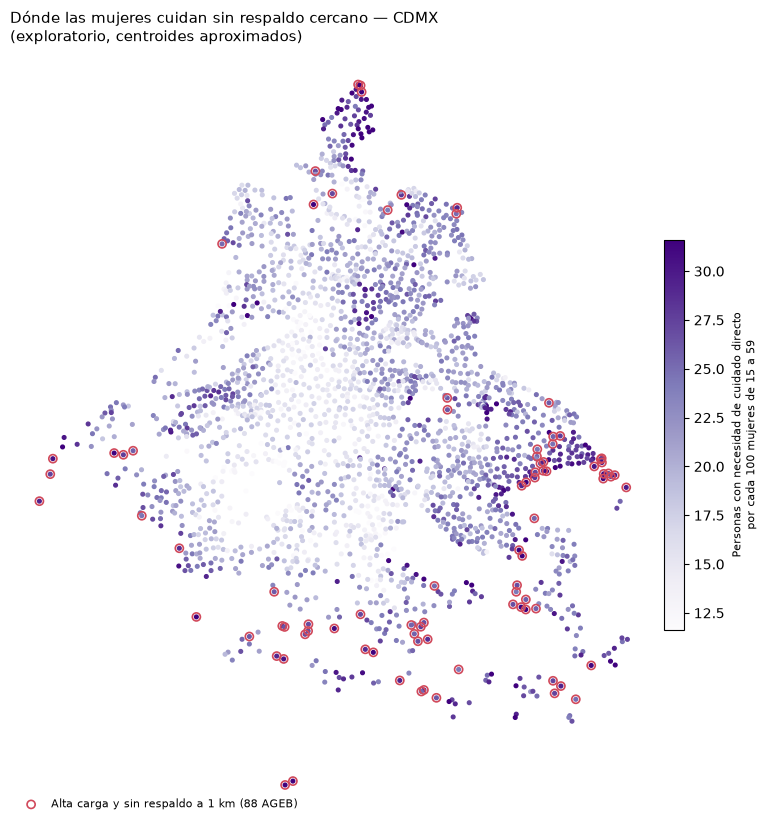

In [18]:
fig, ax = plt.subplots(figsize=(8, 9))
sc = ax.scatter(geo['lon'], geo['lat'], c=geo['carga_directa_x100_mujeres'].clip(upper=geo['carga_directa_x100_mujeres'].quantile(.98)),
                cmap='Purples', s=7, vmin=geo['carga_directa_x100_mujeres'].quantile(.02))
d = geo[geo['sin_respaldo']]
ax.scatter(d['lon'], d['lat'], s=34, facecolors='none', edgecolors='#d1495b', linewidths=1.2,
           label=f'Alta carga y sin respaldo a 1 km ({len(d)} AGEB)')
ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([]); ax.spines[:].set_visible(False)
cb = fig.colorbar(sc, ax=ax, shrink=0.45, pad=0.01)
cb.set_label('Personas con necesidad de cuidado directo\npor cada 100 mujeres de 15 a 59', fontsize=8)
ax.legend(loc='lower left', fontsize=8, frameon=False)
ax.set_title('Dónde las mujeres cuidan sin respaldo cercano — CDMX\n(exploratorio, centroides aproximados)', loc='left', fontsize=11)
plt.tight_layout()
fig.savefig(FIG / 'mujeres_sin_respaldo_ageb.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Resumen de cifras

La interpretación va en el documento del equipo. Aquí solo las cifras, para citarlas sin volver a correr todo.

In [19]:
fila = t.set_index('actividad').loc['Cuidado a integrantes del hogar (total)']
resumen = pd.Series({
    'ENUT · % mujeres CDMX que cuidan': fila['% de mujeres que lo realiza'],
    'ENUT · h/semana mujeres que cuidan': fila['h/semana (mujeres que lo realizan)'],
    'ENUT · ref. h/semana hombres que cuidan': fila['ref. h/semana hombres'],
    'ENUT · jornada total mujeres ocupadas (h)': round(jor.loc['Mujeres ocupadas', 'Total'], 1),
    'ENUT · jornada total hombres ocupados (h, ref.)': round(jor.loc['Hombres ocupados (ref.)', 'Total'], 1),
    'ENASIC · % cuidadoras que buscó un servicio': busco.get('Sí buscó'),
    'ENASIC · % cuidadoras que prefiere cuidado en casa': pref.get('En su casa'),
    'ENASIC · % cuidadoras que sería cuidadora pagada': round(pagada, 1),
    'Censo · carga directa x100 mujeres, CDMX': round(cdmx_tot['carga_directa_x100_mujeres'], 1),
    'Censo · alcaldía con mayor carga': por_alc.index[0],
    'Cruce · AGEB alta carga sin respaldo': int(geo['sin_respaldo'].sum()),
    'Cruce · mujeres 15–59 en esas AGEB': int(geo.loc[geo['sin_respaldo'], 'mujeres_15a59'].sum()),
})
resumen.to_frame('valor')

,valor
ENUT · % mujeres CDMX que cuidan,62.2
ENUT · h/semana mujeres que cuidan,12.2
ENUT · ref. h/semana hombres que cuidan,8.1
ENUT · jornada total mujeres ocupadas (h),77.0
"ENUT · jornada total hombres ocupados (h, ref.)",73.5
ENASIC · % cuidadoras que buscó un servicio,3.2
ENASIC · % cuidadoras que prefiere cuidado en casa,61.2
ENASIC · % cuidadoras que sería cuidadora pagada,44.4
"Censo · carga directa x100 mujeres, CDMX",21.6
Censo · alcaldía con mayor carga,Milpa Alta


---
## 6. Exportación para el tablero

Estas celdas **no recalculan nada**: toman las tablas ya construidas arriba y las guardan en `data/curada/`.
Cada CSV lleva dos columnas de contexto obligatorias, `nivel_geografico` y `fuente`, para que ninguna cifra
se pueda citar sin saber de dónde salió ni a qué territorio se refiere. Es especialmente importante en la
ENASIC: sus cifras son **nacionales** y no deben aparecer en mapas de la CDMX.

In [20]:
# Utilidades de exportación. No modifican ninguna tabla: trabajan sobre una copia.
ENUT_FTE   = 'INEGI, ENUT 2024'
ENASIC_FTE = 'INEGI, ENASIC 2022'

def exportar(df, archivo, nivel, fuente):
    out = df.copy()
    out['nivel_geografico'] = nivel
    out['fuente'] = fuente
    out.to_csv(CUR / archivo, index=False)
    print(f'{archivo:42} {len(out):>4} filas x {out.shape[1]:>2} columnas')
    return out

# --- ENUT 2024 (CDMX) -------------------------------------------------------
# jor se exporta redondeada a 1 decimal, igual que se muestra en la sección 1.2.
exportar(jor.round(1).rename_axis('grupo').reset_index(),
         'mujeres_doble_jornada_cdmx.csv', 'CDMX', ENUT_FTE)

exportar(por_cond.rename_axis('condicion').reset_index(),
         'mujeres_cuidado_por_condicion.csv', 'CDMX', ENUT_FTE)

exportar(por_edad.rename_axis('grupo_edad').reset_index(),
         'mujeres_cuidado_por_edad.csv', 'CDMX', ENUT_FTE)

mujeres_doble_jornada_cdmx.csv                2 filas x  8 columnas
mujeres_cuidado_por_condicion.csv             6 filas x  7 columnas
mujeres_cuidado_por_edad.csv                  5 filas x  7 columnas


,grupo_edad,h/semana de cuidado (promedio por mujer),% que cuida,n,confiable,nivel_geografico,fuente
0,12–17,3.4,58.7,65,sí,CDMX,"INEGI, ENUT 2024"
1,18–29,8.5,74.8,213,sí,CDMX,"INEGI, ENUT 2024"
2,30–44,14.3,71.9,288,sí,CDMX,"INEGI, ENUT 2024"
3,45–59,5.5,61.2,269,sí,CDMX,"INEGI, ENUT 2024"
4,60+,3.3,45.8,309,sí,CDMX,"INEGI, ENUT 2024"


In [21]:
# --- ENASIC 2022 (nacional) -------------------------------------------------
exportar(busco.rename_axis('respuesta').reset_index(name='% de mujeres cuidadoras'),
         'enasic_busqueda_servicios.csv', 'Nacional', ENASIC_FTE)

# Respuesta múltiple: los porcentajes no suman 100. Base = mujeres cuidadoras que NO buscaron.
exportar(razones.rename_axis('razon').reset_index(name='% de mujeres cuidadoras que no buscaron'),
         'enasic_razones_no_buscar.csv', 'Nacional', ENASIC_FTE)

exportar(pref.rename_axis('preferencia').reset_index(name='% de mujeres cuidadoras'),
         'enasic_preferencia_cuidado.csv', 'Nacional', ENASIC_FTE)

exportar(pd.DataFrame({
             'indicador': ['Le gustaría ser cuidadora profesional si le pagaran',
                           'Estaría dispuesta a capacitarse para ser cuidadora'],
             '% de mujeres cuidadoras': [round(pagada, 1), round(capac, 1)],
         }),
         'enasic_disposicion_cuidar.csv', 'Nacional', ENASIC_FTE)

enasic_busqueda_servicios.csv                 2 filas x  4 columnas
enasic_razones_no_buscar.csv                 10 filas x  4 columnas
enasic_preferencia_cuidado.csv                5 filas x  4 columnas
enasic_disposicion_cuidar.csv                 2 filas x  4 columnas


,indicador,% de mujeres cuidadoras,nivel_geografico,fuente
0,Le gustaría ser cuidadora profesional si le pa...,44.4,Nacional,"INEGI, ENASIC 2022"
1,Estaría dispuesta a capacitarse para ser cuida...,42.8,Nacional,"INEGI, ENASIC 2022"


In [22]:
# --- Resumen de cifras clave ------------------------------------------------
# Aquí el nivel y la fuente cambian fila por fila, así que se derivan del prefijo de cada clave.
CONTEXTO = {
    'ENUT':   (ENUT_FTE,                                     'CDMX'),
    'ENASIC': (ENASIC_FTE,                                   'Nacional'),
    'Censo':  ('INEGI, Censo de Población y Vivienda 2020',  'CDMX'),
    'Cruce':  ('INEGI, Censo 2020 + DENUE 05/2026',          'CDMX'),
}
cifras = resumen.rename_axis('clave').reset_index(name='valor')
prefijo = cifras['clave'].str.split('·').str[0].str.strip()
faltantes = sorted(set(prefijo) - set(CONTEXTO))
assert not faltantes, f'Prefijos sin contexto definido: {faltantes}'
cifras['nivel_geografico'] = prefijo.map(lambda p: CONTEXTO[p][1])
cifras['fuente'] = prefijo.map(lambda p: CONTEXTO[p][0])
cifras.to_csv(CUR / 'resumen_cifras_clave.csv', index=False)
print(f'{"resumen_cifras_clave.csv":42} {len(cifras):>4} filas x {cifras.shape[1]:>2} columnas')
cifras

resumen_cifras_clave.csv                     12 filas x  4 columnas


,clave,valor,nivel_geografico,fuente
0,ENUT · % mujeres CDMX que cuidan,62.2,CDMX,"INEGI, ENUT 2024"
1,ENUT · h/semana mujeres que cuidan,12.2,CDMX,"INEGI, ENUT 2024"
2,ENUT · ref. h/semana hombres que cuidan,8.1,CDMX,"INEGI, ENUT 2024"
3,ENUT · jornada total mujeres ocupadas (h),77.0,CDMX,"INEGI, ENUT 2024"
4,"ENUT · jornada total hombres ocupados (h, ref.)",73.5,CDMX,"INEGI, ENUT 2024"
5,ENASIC · % cuidadoras que buscó un servicio,3.2,Nacional,"INEGI, ENASIC 2022"
6,ENASIC · % cuidadoras que prefiere cuidado en ...,61.2,Nacional,"INEGI, ENASIC 2022"
7,ENASIC · % cuidadoras que sería cuidadora pagada,44.4,Nacional,"INEGI, ENASIC 2022"
8,"Censo · carga directa x100 mujeres, CDMX",21.6,CDMX,"INEGI, Censo de Población y Vivienda 2020"
9,Censo · alcaldía con mayor carga,Milpa Alta,CDMX,"INEGI, Censo de Población y Vivienda 2020"
